# JAX Heat Equation Source Inversion Notebook

## Overview

This notebook demonstrates **PDE-constrained inverse optimization** for the 1D heat equation using **JAX** with automatic differentiation. The goal is to solve an **inverse problem**: given noisy temperature measurements, recover the unknown spatial heat source that produced them.

### The Inverse Problem

**Forward problem (well-posed):**
- Given: heat source $s(x)$, initial/boundary conditions
- Find: temperature field $u(x,t)$ by solving the heat PDE

**Inverse problem (ill-posed):**
- Given: noisy temperature observations $y$ at certain locations/times
- Find: heat source $s(x)$ that best explains the observations

This is a classic **parameter estimation** problem in PDE-constrained optimization, with applications in:
- Thermal imaging and non-destructive testing
- Climate modeling (estimating heat sources/sinks)
- Medical imaging (thermal ablation planning)
- Manufacturing process control

### Approach

We solve the inverse problem using:
1. **Gradient-based optimization** (Adam) to minimize data misfit + regularization
2. **Automatic differentiation** through the PDE solver (JAX's key advantage)
3. **Three experiment types** to explore different observation scenarios

### References

- **Primary inspiration:** "Physics-Informed Differentiable Programs for PDE-Constrained Inverse Problems" ([arXiv:2408.12404](https://arxiv.org/pdf/2408.12404)) — uses PyTorch; we implement a pure JAX baseline without neural networks
- **Team prototype:** [`markm39/pde-constrained-opt-nn`](https://github.com/markm39/pde-constrained-opt-nn/blob/main/1d_heat_force_vector.ipynb)

### Key Features

**No neural networks** — purely deterministic optimization   
**CPU-only** — avoids macOS Metal backend issues  
**Fully differentiable** — JAX autodiff through PDE solver  
**Branch-free** — no tracer errors from Python conditionals

## 1. CPU-safe environment & imports
We force JAX to stay on the CPU and point Matplotlib to a local cache directory so the notebook runs reliably on macOS without Metal support.


In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")
os.environ.setdefault("MPLCONFIGDIR", os.path.join(os.getcwd(), "_mpl-cache"))
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)


In [2]:
import time
from functools import partial

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np


## 2. Discretisation hyper-parameters
The forward model solves
$u_t = \kappa u_{xx} + s(x)$ with homogeneous Dirichlet boundaries and zero initial condition. We discretise the interior of the unit interval with a uniform grid, apply implicit Euler in time, and drop the boundary nodes.


In [3]:
xmin, xmax = 0.0, 1.0
T = 0.1
Nx = 129          # includes Dirichlet boundary nodes
Nt = 200
kappa = 1.0
noise_std = 1e-3

x_full = jnp.linspace(xmin, xmax, Nx)
x_interior = x_full[1:-1]
dx = (xmax - xmin) / (Nx - 1)
dt = T / Nt

print(f"Interior DOFs: {x_interior.shape[0]}, dx={dx:.4e}, dt={dt:.4e}")


Interior DOFs: 127, dx=7.8125e-03, dt=5.0000e-04


## 3. Linear algebra primitives
We build a tridiagonal Thomas solver and an implicit Euler step function, both JIT-ready and branch-free so that `jax.grad` works without tracer conversion errors.


In [4]:
def solve_tridiag(main, off, rhs):
    '''Solve tri-diagonal systems via Thomas algorithm using JAX scans.'''
    main = jnp.asarray(main)
    rhs = jnp.asarray(rhs)
    off = jnp.asarray(off)
    n = main.shape[0]

    if n == 1:
        return rhs / main

    off_pad = jnp.concatenate([off, jnp.zeros((1,), dtype=off.dtype)])

    denom0 = main[0]
    d0 = rhs[0] / denom0
    c0 = off_pad[0] / denom0

    def forward(carry, i):
        c_prev, d_prev = carry
        idx = i + 1
        denom = main[idx] - off[idx - 1] * c_prev
        d_curr = (rhs[idx] - off[idx - 1] * d_prev) / denom
        c_curr = off_pad[idx] / denom
        return (c_curr, d_curr), (c_curr, d_curr)

    (_, _), (c_tail, d_tail) = jax.lax.scan(forward, (c0, d0), jnp.arange(n - 1))
    c_seq = jnp.concatenate([jnp.array([c0]), c_tail])
    d_seq = jnp.concatenate([jnp.array([d0]), d_tail])

    x_last = d_seq[-1]

    def backward(carry, inputs):
        c_i, d_i = inputs
        x_i = d_i - c_i * carry
        return x_i, x_i

    rev_inputs = (jnp.flip(c_seq[:-1]), jnp.flip(d_seq[:-1]))
    _, rev_sol = jax.lax.scan(backward, x_last, rev_inputs)
    sol = jnp.concatenate([jnp.flip(rev_sol), jnp.array([x_last])])
    return sol


def make_stepper(nx, dx, dt, kappa):
    alpha = kappa * dt / (dx * dx)
    n_inner = nx - 2
    main = jnp.full((n_inner,), 1.0 + 2.0 * alpha)
    off = jnp.full((n_inner - 1,), -alpha)

    @jax.jit
    def step(u, s):
        rhs = u + dt * s
        return solve_tridiag(main, off, rhs)

    return step


def rollout(u0, s, step_fn, nt):
    def body(u, _):
        u_next = step_fn(u, s)
        return u_next, u_next

    final_u, traj = jax.lax.scan(body, u0, None, length=nt)
    return final_u, traj


## 4. Losses and synthetic data
We measure the misfit for three experiment types and add Tikhonov regularisation. Synthetic observations are generated from a known source $s_{\text{true}}(x) = \sin(2\pi x)$ with configurable noise.


In [5]:
def generate_true_source(nx):
    interior = jnp.linspace(xmin + dx, xmax - dx, nx - 2)
    return jnp.sin(2.0 * jnp.pi * interior)


def generate_observations(step_fn, u0, s_true, nt, noise_std, key, num_sensors=16):
    uT, traj = rollout(u0, s_true, step_fn, nt)

    key_final, key_sparse, key_multi = jax.random.split(key, 3)

    noise_final = noise_std * jax.random.normal(key_final, uT.shape)
    y_final = uT + noise_final

    sensor_idx = np.linspace(0, uT.shape[0] - 1, num=num_sensors, dtype=int)
    noise_sparse = noise_std * jax.random.normal(key_sparse, (sensor_idx.size,))
    y_sparse = uT[sensor_idx] + noise_sparse

    t_indices = jnp.array([int(0.3 * nt), int(0.6 * nt), nt])
    t_indices = jnp.clip(t_indices, 1, nt)
    snapshots = jnp.take(traj, t_indices - 1, axis=0)
    noise_multi = noise_std * jax.random.normal(key_multi, snapshots.shape)
    y_multi = snapshots + noise_multi

    return {
        "y_final": y_final,
        "sensor_idx": jnp.array(sensor_idx),
        "y_sparse": y_sparse,
        "t_indices": t_indices,
        "y_multi": y_multi,
    }


def loss_finaltime(s, u0, y_final, step_fn, nt, lam):
    uT, _ = rollout(u0, s, step_fn, nt)
    misfit = uT - y_final
    data_term = 0.5 * jnp.sum(misfit ** 2)
    reg = 0.5 * lam * jnp.sum(s ** 2)
    return data_term + reg


def loss_sparsepoints(s, u0, idx, y_sparse, step_fn, nt, lam):
    uT, _ = rollout(u0, s, step_fn, nt)
    misfit = uT[idx] - y_sparse
    data_term = 0.5 * jnp.sum(misfit ** 2)
    reg = 0.5 * lam * jnp.sum(s ** 2)
    return data_term + reg


def loss_multitime(s, u0, y_all, step_fn, nt, t_indices, lam):
    _, traj = rollout(u0, s, step_fn, nt)
    snapshots = jnp.take(traj, t_indices - 1, axis=0)
    misfit = snapshots - y_all
    data_term = 0.5 * jnp.sum(misfit ** 2)
    reg = 0.5 * lam * jnp.sum(s ** 2)
    return data_term + reg


In [6]:
step_fn = make_stepper(Nx, dx, dt, kappa)

u0 = jnp.zeros((Nx - 2,))
s_true = generate_true_source(Nx)

key = jax.random.PRNGKey(0)
obs = generate_observations(step_fn, u0, s_true, Nt, noise_std, key)

print("Observation shapes:")
for k, v in obs.items():
    print(f"  {k}: {v.shape}")


Observation shapes:
  y_final: (127,)
  sensor_idx: (16,)
  y_sparse: (16,)
  t_indices: (3,)
  y_multi: (3, 127)


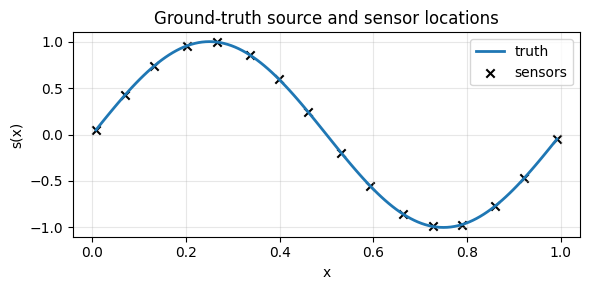

In [7]:
plt.figure(figsize=(6, 3))
plt.plot(x_interior, np.asarray(s_true), label="truth", linewidth=2)
plt.scatter(
    x_interior[np.asarray(obs["sensor_idx"])],
    np.asarray(s_true)[np.asarray(obs["sensor_idx"])] ,
    marker="x",
    color="black",
    label="sensors",
)
plt.title("Ground-truth source and sensor locations")
plt.xlabel("x")
plt.ylabel("s(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Optimiser helper
We stick to a hand-rolled Adam loop to avoid external dependencies. The loss and gradient functions will be JIT-compiled per experiment for performance.


In [8]:
def run_adam(loss_fn, grad_fn, s_init, steps, lr, beta1=0.9, beta2=0.999, eps=1e-8):
    s = s_init
    m = jnp.zeros_like(s)
    v = jnp.zeros_like(s)
    loss_history = []
    beta1_power = 1.0
    beta2_power = 1.0

    for _ in range(1, steps + 1):
        loss_val = loss_fn(s)
        grad_val = grad_fn(s)
        m = (1.0 - beta1) * grad_val + beta1 * m
        v = (1.0 - beta2) * (grad_val ** 2) + beta2 * v
        beta1_power *= beta1
        beta2_power *= beta2
        m_hat = m / (1.0 - beta1_power)
        v_hat = v / (1.0 - beta2_power)
        s = s - lr * m_hat / (jnp.sqrt(v_hat) + eps)
        loss_history.append(float(loss_val))

    return s, np.array(loss_history)


## 6. Experiment suite (Exp A/B/C)
- **Exp A:** full field at final time $ t=T $
- **Exp B:** sparse final-time sensors (16 points)
- **Exp C:** full field snapshots at $ 0.3T, 0.6T, T $

Each experiment shares the same forward model but differs in measurement operator and regularisation. The hyperparameters mirror the standalone script so generated PNGs align with the notebook's plots.


In [9]:
experiments = [
    {
        "name": "Exp A",
        "loss": partial(loss_finaltime, u0=u0, y_final=obs["y_final"], step_fn=step_fn, nt=Nt, lam=1e-4),
        "lr": 0.05, #1.15
        "steps": 1500,
    },
    {
        "name": "Exp B",
        "loss": partial(
            loss_sparsepoints,
            u0=u0,
            idx=obs["sensor_idx"],
            y_sparse=obs["y_sparse"],
            step_fn=step_fn,
            nt=Nt,
            lam=1e-5,
        ),
        "lr": 0.02,
        "steps": 2500,
    },
    {
        "name": "Exp C",
        "loss": partial(
            loss_multitime,
            u0=u0,
            y_all=obs["y_multi"],
            step_fn=step_fn,
            nt=Nt,
            t_indices=obs["t_indices"],
            lam=1e-4,
        ),
        "lr": 0.05,
        "steps": 3000,
    },
]

results = []

for cfg in experiments:
    loss_fn = jax.jit(cfg["loss"])
    grad_fn = jax.jit(jax.grad(cfg["loss"]))

    s0 = jnp.zeros_like(s_true)
    start = time.time()
    s_est, losses = run_adam(loss_fn, grad_fn, s0, cfg["steps"], cfg["lr"])
    duration = time.time() - start

    rel_err = float(jnp.linalg.norm(s_est - s_true) / jnp.linalg.norm(s_true))
    print(f"{cfg['name']}: relative error={rel_err:.4f}, duration={duration:.2f}s")

    results.append({
        "cfg": cfg,
        "s_est": s_est,
        "losses": losses,
        "rel_err": rel_err,
    })


Exp A: relative error=0.1386, duration=3.50s
Exp B: relative error=0.1414, duration=5.38s
Exp C: relative error=0.0659, duration=11.41s


## 7. Visualise convergence and reconstructions
Loss histories are shown on a semi-log scale, and the recovered source is compared against the truth. For Exp B we mark the sensor positions for clarity.


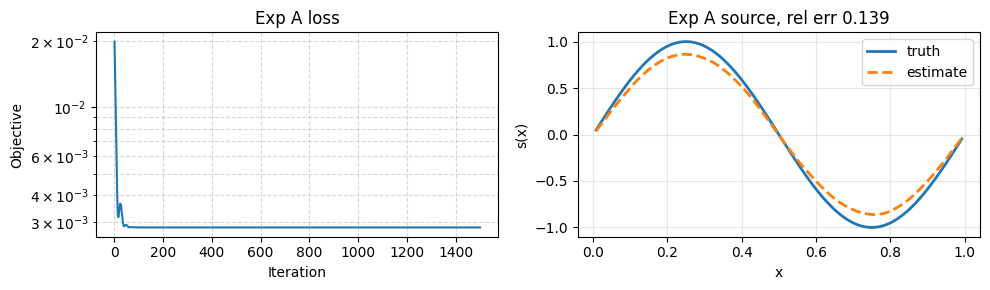

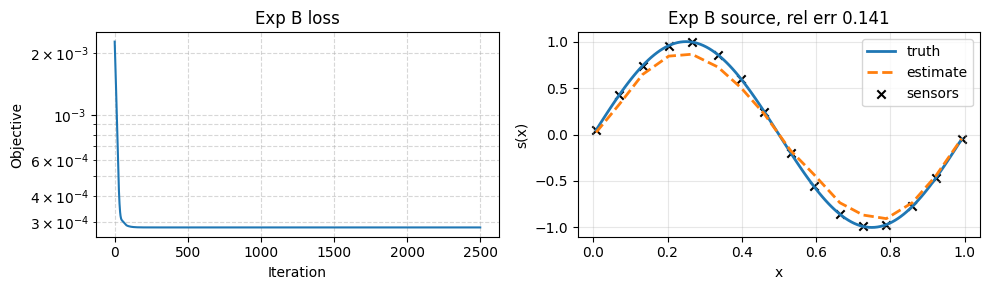

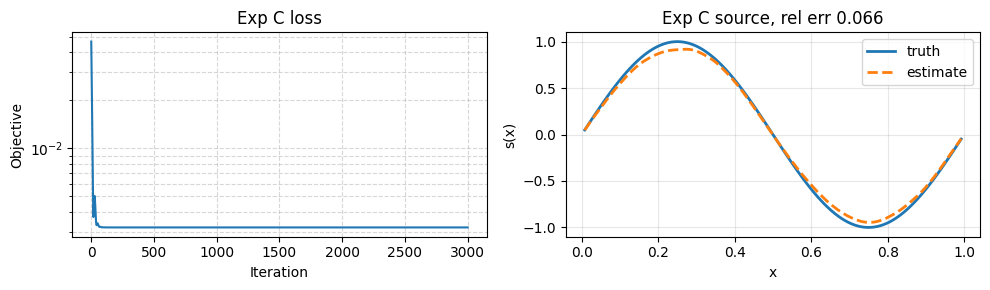

In [10]:
for res in results:
    cfg = res["cfg"]
    losses = res["losses"]
    s_est = res["s_est"]

    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    ax[0].semilogy(np.arange(1, losses.size + 1), losses)
    ax[0].set_title(f"{cfg['name']} loss")
    ax[0].set_xlabel("Iteration")
    ax[0].set_ylabel("Objective")
    ax[0].grid(True, which="both", ls="--", alpha=0.5)

    ax[1].plot(x_interior, np.asarray(s_true), label="truth", linewidth=2)
    ax[1].plot(x_interior, np.asarray(s_est), label="estimate", linestyle="--", linewidth=2)
    if cfg["name"] == "Exp B":
        ax[1].scatter(
            x_interior[np.asarray(obs["sensor_idx"])],
            np.asarray(s_true)[np.asarray(obs["sensor_idx"])],
            marker="x",
            color="black",
            label="sensors",
        )
    ax[1].set_title(f"{cfg['name']} source, rel err {res['rel_err']:.3f}")
    ax[1].set_xlabel("x")
    ax[1].set_ylabel("s(x)")
    ax[1].grid(True, alpha=0.3)
    ax[1].legend()
    plt.tight_layout()
    plt.show()


## 8. Takeaways
- JAX's functional control flow (`lax.scan`) keeps the implicit Euler integrator differentiable and avoids tracer boolean pitfalls that often crop up in hand-written loops.
- Future extensions: replace Adam with `jaxopt` solvers, move to 2-D geometries.